In [1]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime

# local imports
import sys
sys.path.append('../../../')
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.scripts.get_systematics import get_systematics
from pyanalib.covariance import *
from makedf.mcstat import get_MCstat_unc
from makedf.geniesyst import *

# # turn off PerformanceWarning 
# # triggered by mismatched column levels
# import warnings
# warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

mc_n_split: 1
mc_tot_pot: 1.518e+19
Integrated flux: 2.452e+11
# of targets:  1.3251484770937053e+30
XSEC_UNIT is 0, setting to 1e-38
xsec unit:  1e-38


/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/notebooks/../../../analysis_village/numucc_1p0pi/constants.py:56: RuntimeWarning: overflow encountered in scalar multiply
  xsec_unit = 1 / (integrated_flux * NTARGETS)


In [2]:
genie_tag = "MEC"

syst_type = f"genie-{genie_tag}"
syst_list = mec_genie_systematics
df_tag = ""
subdir = f"genie_wgts-{genie_tag}"

In [149]:
# ===== files to process =====
file_dir = "/pnfs/sbnd/scratch/users/munjung/xsec/2025Spring_v10_06_00_09"
n_max_concat = 3
mc_keys2load = ['hdr', 'mcnu', 'evt'] 

# df_tag="_geniewgts_CCQE"
# subdir = "genie_wgts-CCQE"
concat_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    chunk_tags=generate_tags("ad"),
    df_tag=df_tag,
    keys2load=mc_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="MC",
    sample_dir="BNB_cosmics/"+subdir
)

mc_hdr_df = concat_dfs['hdr']
mc_nu_df  = concat_dfs['mcnu']
mc_evt_df = concat_dfs['evt']

# ===== total pot =====
mc_tot_pot = mc_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))
mc_pot_scale = 1.0
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
mc_nu_df["pot_weight"]  = mc_pot_scale * np.ones(len(mc_nu_df))


Reading file with tag aa, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag ab, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
Reading file with tag ac, mc_n_split: 1
Keys: ['/evt_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/mcnu_0', '/split']
mc_tot_pot: 4.562e+19


In [136]:
multisim_nuniv = 100
slimname = "GENIE_test"
s = "GENIEReWeight_SBN_v1_multisigma_DecayAngMEC"

In [137]:
nuidx = mc_evt_df.index

cols = pd.MultiIndex.from_product(
    [[slimname], [f"univ_{i}" for i in range(multisim_nuniv)]],
)
systs_slim = pd.DataFrame(
    1.0,
    index=nuidx,
    columns=cols,
)

s_morph = mc_evt_df.mc[s].morph

for i in range(multisim_nuniv):
    seed_input = s + str(i)
    np.random.seed(hash(seed_input) % (2**32))
    # wgt = 1 + (s_morph - 1) * 2 * np.abs(np.random.normal(0, 1)) # std -> unc.
    wgt = 1 + (s_morph - 1) * np.abs(np.random.normal(0, 1)) # std -> unc.
    systs_slim[(slimname, f"univ_{i}")] = systs_slim[(slimname, f"univ_{i}")].values * wgt

    mc_evt_df[("mc", s, f"univ_{i}", "", "", "", "")] = systs_slim[(slimname, f"univ_{i}")].copy()

In [138]:
nuidx = mc_nu_df.index

cols = pd.MultiIndex.from_product(
    [[slimname], [f"univ_{i}" for i in range(multisim_nuniv)]],
)
systs_slim = pd.DataFrame(
    1.0,
    index=nuidx,
    columns=cols,
)

s_morph = mc_nu_df.mc[s].morph

for i in range(multisim_nuniv):
    seed_input = s + str(i)
    np.random.seed(hash(seed_input) % (2**32))
    # wgt = 1 + (s_morph - 1) * 2 * np.abs(np.random.normal(0, 1)) # std -> unc.
    wgt = 1 + (s_morph - 1) * np.abs(np.random.normal(0, 1)) # std -> unc.
    systs_slim[(slimname, f"univ_{i}")] = systs_slim[(slimname, f"univ_{i}")].values * wgt

    mc_nu_df[("mc", s, f"univ_{i}", "")] = systs_slim[(slimname, f"univ_{i}")].copy()

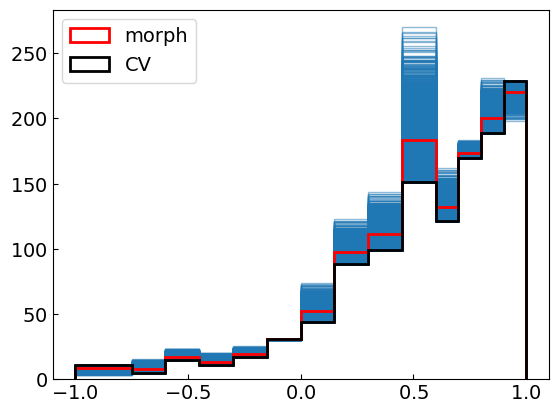

In [126]:
var_config = VariableConfig.muon_direction()

mec_evt_df = mc_evt_df[mc_evt_df.mc.genie_mode == 10]
var = mec_evt_df[var_config.var_evt_reco_col]

n_list = []
for i in range(multisim_nuniv):
    weights = mec_evt_df.mc[s, f"univ_{i}", "", "", "", ""]
    # weights = weights.fillna(1)
    n, _, _ = plt.hist(var, bins=var_config.bins, weights=weights, histtype="step", color="C0", alpha=0.5)
    n_list.append(n)

# bin-by-bin standard deviation of universe
n_list = np.array(n_list)
# n_list_std = np.std(n_list, axis=0)

orig_wgt = mec_evt_df.mc[s, "morph", "", "", "", ""]
# orig_wgt = orig_wgt.fillna(1)
n_morph, _, _ = plt.hist(var, bins=var_config.bins, weights=orig_wgt, histtype="step", color="red", linewidth=2, label="morph")
n_cv, _, _ = plt.hist(var, bins=var_config.bins, histtype="step", color="black", linewidth=2, label="CV")

plt.legend()
plt.show();

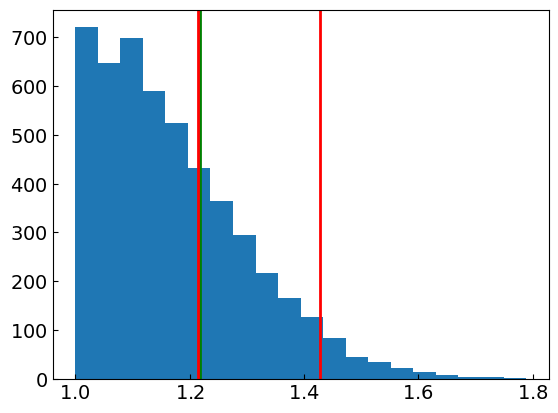

In [127]:
ratios = n_list / n_cv
this_bin_ratio = ratios[:, -5]
this_bin_morph = n_morph[-5] / n_cv[-5]
plt.hist(this_bin_ratio, bins=20)

mirror = list(this_bin_ratio-1) + list(1 - this_bin_ratio)
std = np.std(mirror)
plt.axvline(1+std, color="green", linewidth=2)

plt.axvline(this_bin_morph, color="red", linewidth=2)
plt.axvline(1+(this_bin_morph-1)*2, color="red", linewidth=2)
plt.show();

In [145]:
def get_systematics(mc_evt_df, mc_nu_df, var_config, syst_name, syst_type="genie", plot=False, save_fig=False, save_fig_dir=None):
    # ===== get universes =====
    # Note: these are background subtracted
    matrices = {}
    n_univ = len([c for c in mc_evt_df[syst_name].columns if "univ" in c[0]])
    for cov_type in ["xsec", "rate"]:
        univ_events, cv_events = get_univ_rates(cov_type, mc_evt_df, mc_nu_df, var_config, syst_name, n_univ)
        ret = get_covariance_matrix(univ_events, cv_events)
        save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-univ_hists"
        plot_univ_hists(univ_events, cv_events, syst_name, var_config, plot=plot, save_fig=save_fig, save_name=save_name)
        matrices[cov_type] = ret

        # ===== plot covariance matrices =====
        matrix_type = "cov"
        plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Covariance"]
        save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-{matrix_type}"
        plot_heatmap(ret[matrix_type], 
                    var_config.bins, 
                    plot_labels=plot_labels,
                    plot=plot,
                    save_fig=save_fig, save_name=save_name)

        matrix_type = "cov_frac"
        plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Fractional Covariance"]
        save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-{matrix_type}"
        plot_heatmap(ret[matrix_type], 
                    var_config.bins, 
                    plot_labels=plot_labels,
                    plot=plot,
                    save_fig=save_fig, save_name=save_name)

        matrix_type = "corr"
        plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Correlation"]
        save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-{matrix_type}"
        plot_heatmap(ret[matrix_type], 
                    var_config.bins, 
                    plot_labels=plot_labels,
                    plot=plot,
                    save_fig=save_fig, save_name=save_name)

    return matrices

getting 100 universes for ('mc', 'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC') uncertainty on the xsec


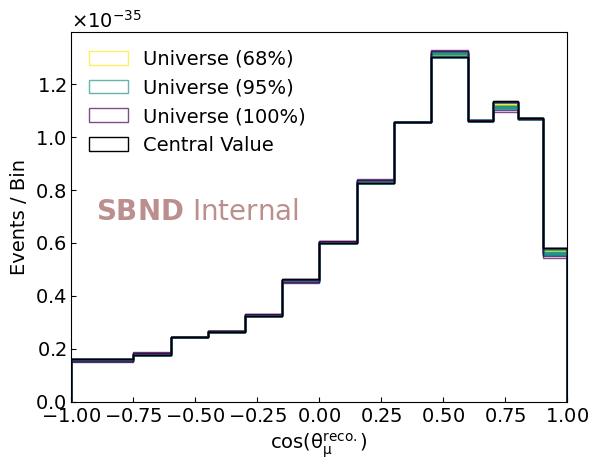

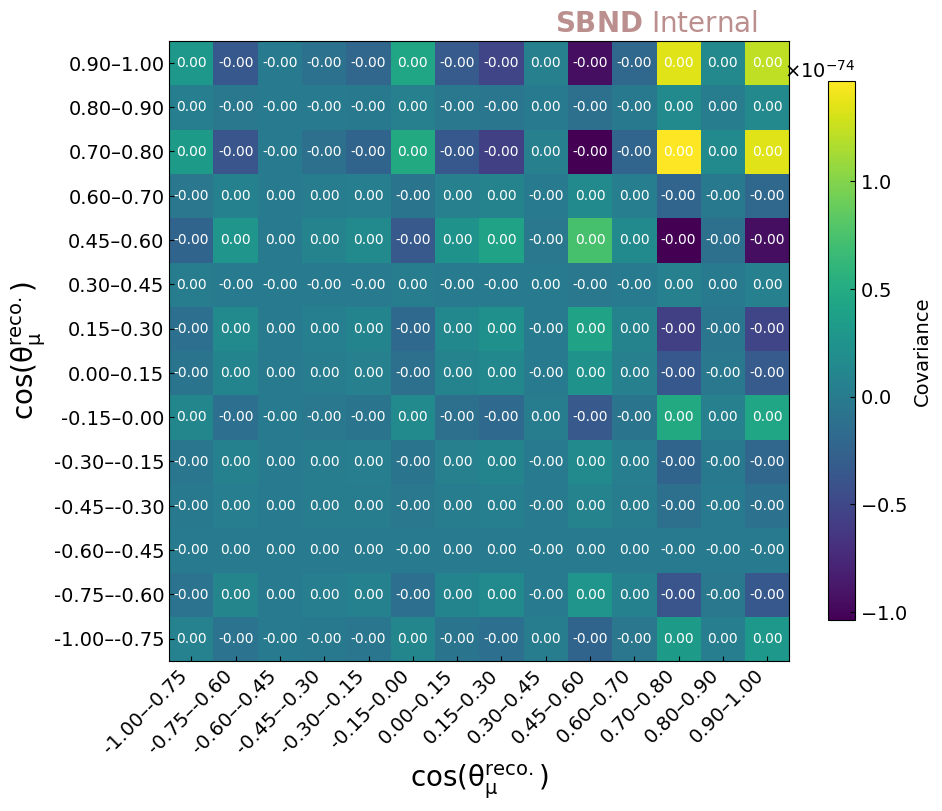

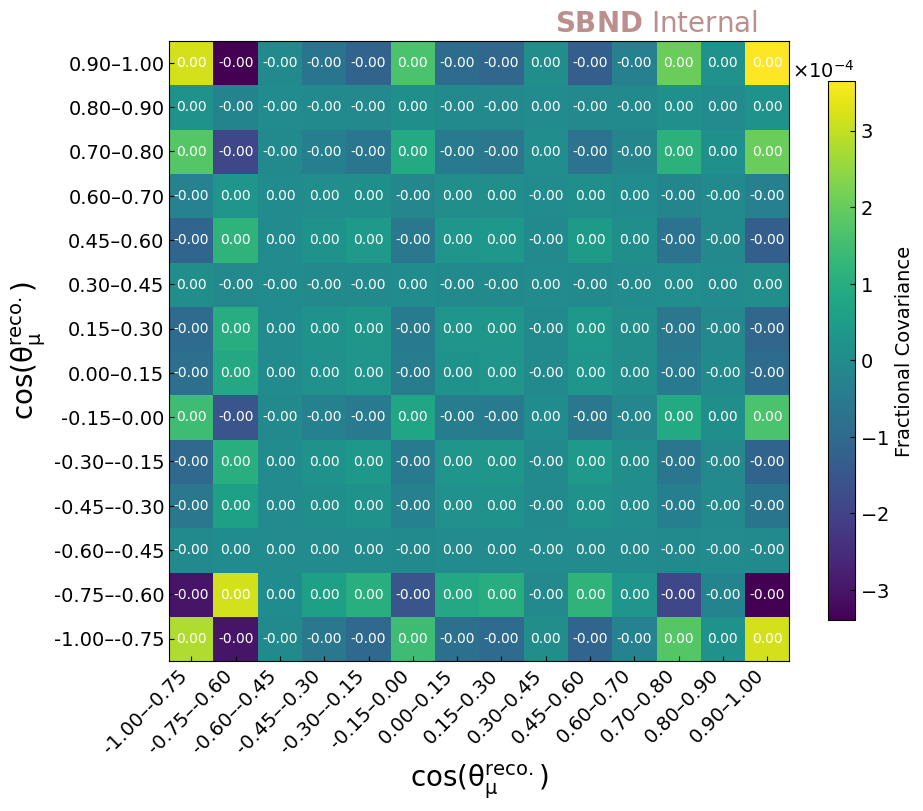

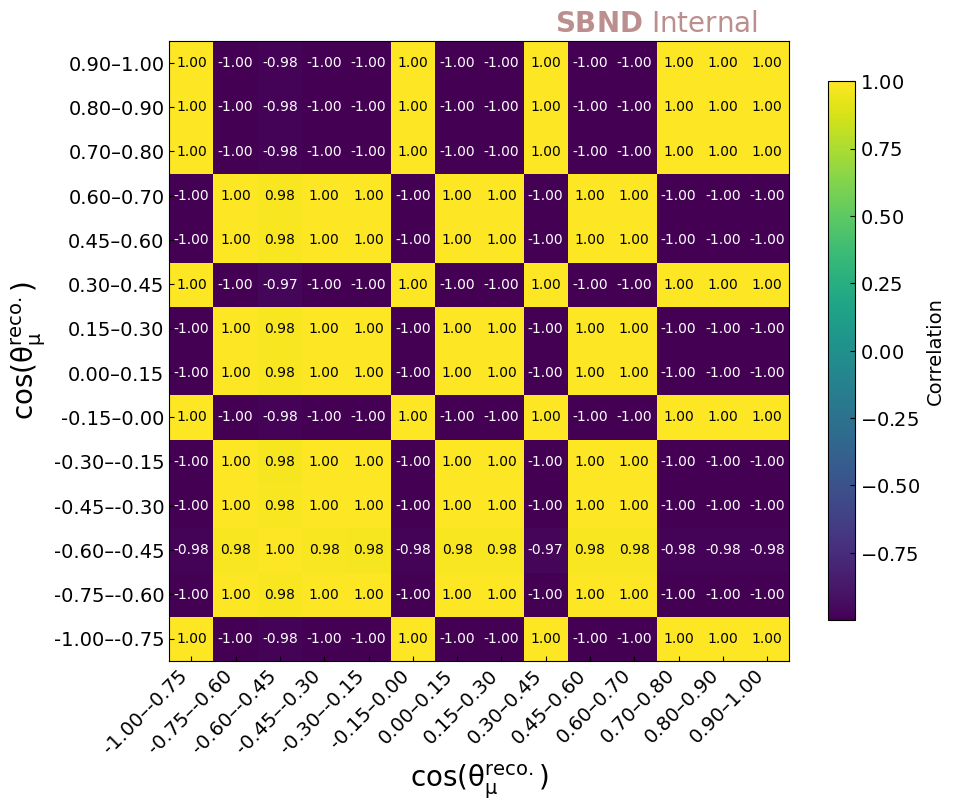

getting 100 universes for ('mc', 'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC') uncertainty on the event rate


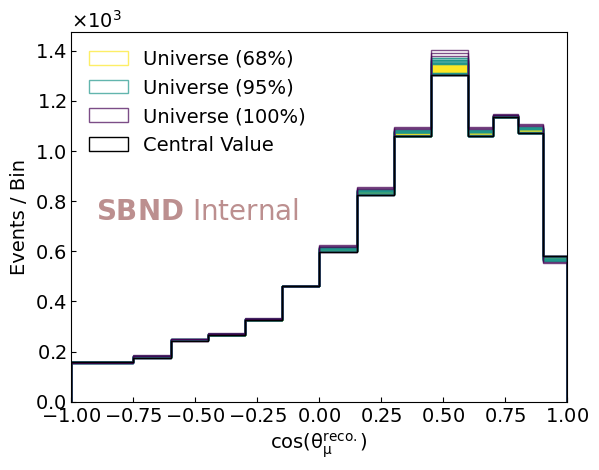

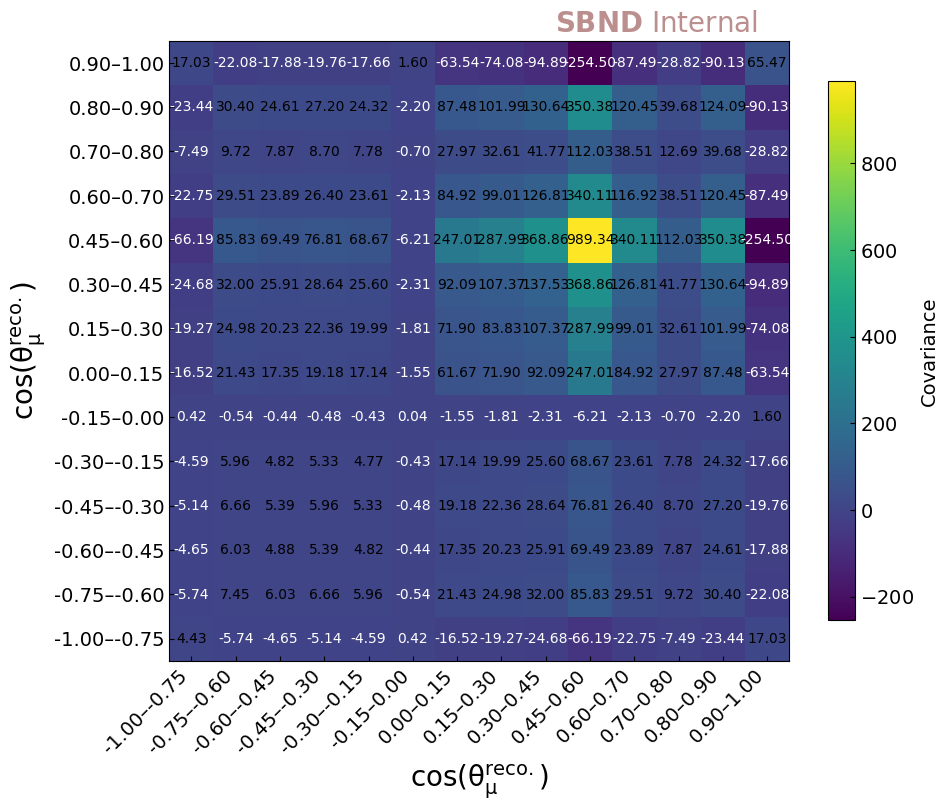

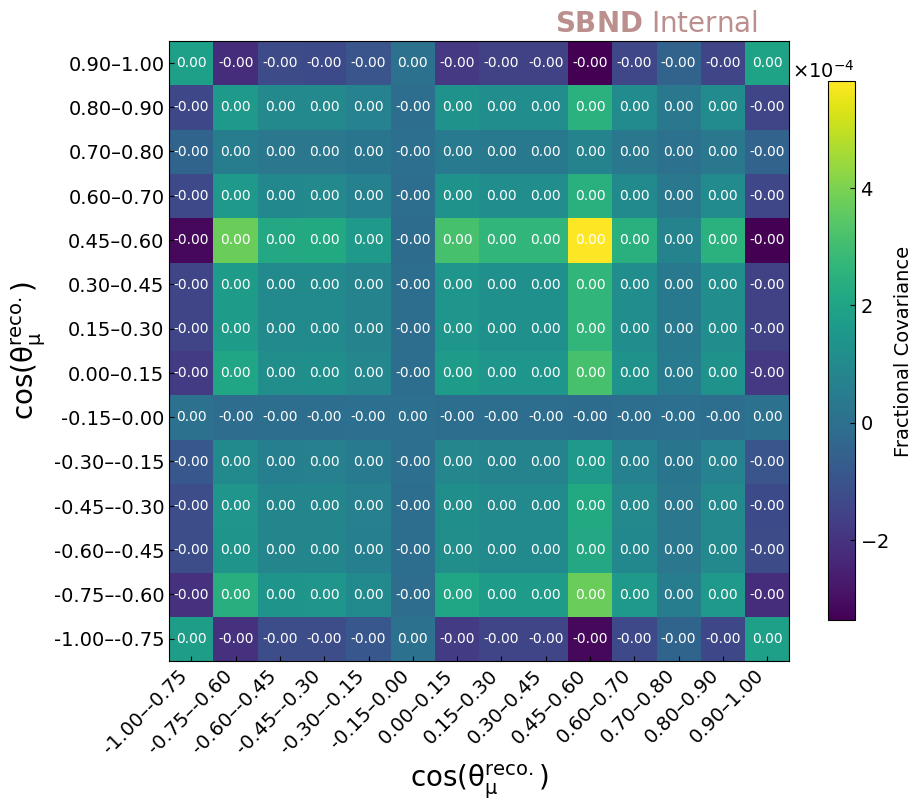

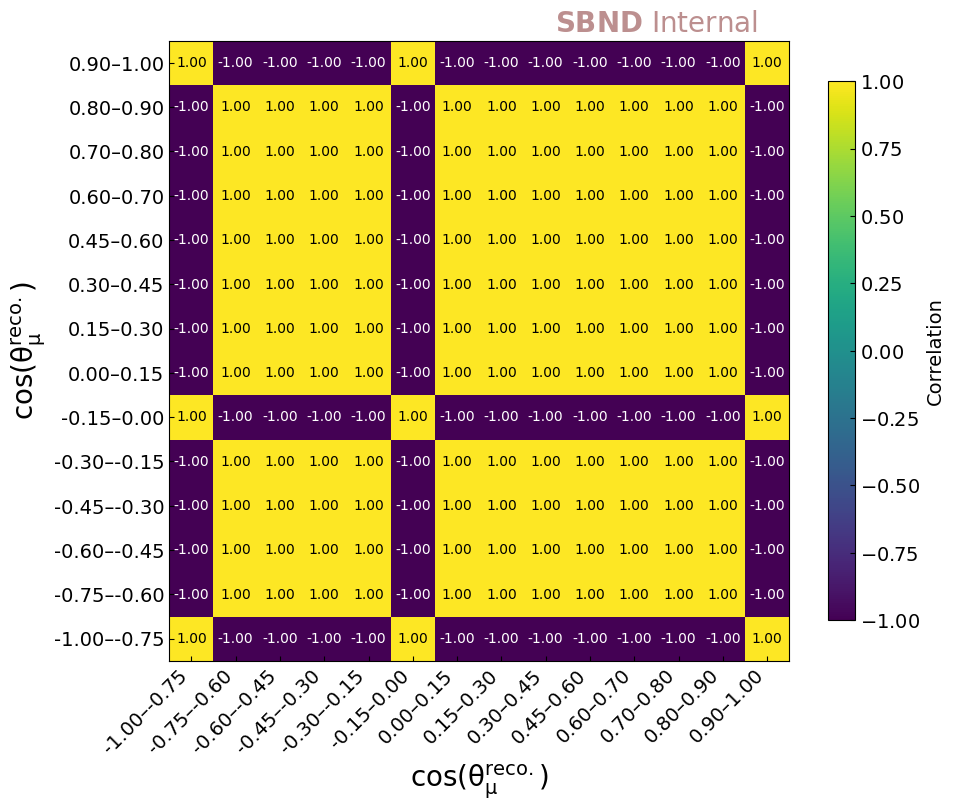

In [ ]:
syst_name = ("mc", s)
matrices = get_systematics(mc_evt_df, mc_nu_df, var_config, syst_name, plot=True)